<a href="https://colab.research.google.com/github/woo-jungnam/th-deep/blob/main/bcao2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dự đoán bệnh tiểu đường với ANN

Để bắt đầu, chúng ta cần cài đặt các thư viện cần thiết như TensorFlow (để xây dựng mô hình ANN), scikit-learn (để tiền xử lý dữ liệu và đánh giá mô hình), pandas (để quản lý dữ liệu) và numpy (để xử lý số học).

In [1]:
import sys

# Install required libraries
!{sys.executable} -m pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

Tiếp theo, chúng ta sẽ tải xuống tập dữ liệu Pima Indians Diabetes. Tập dữ liệu này có thể được tìm thấy trên Kaggle hoặc UCI Machine Learning Repository. Để đơn giản, tôi sẽ giả định rằng tập dữ liệu có sẵn dưới dạng CSV và tải nó trực tiếp từ một URL phổ biến hoặc yêu cầu người dùng tải lên.

In [2]:
import pandas as pd

# Load the Pima Indians Diabetes Dataset
# You can upload your 'diabetes.csv' file to your Colab environment,
# or uncomment the line below to download it from a common source if available.
# Make sure the file name matches if you upload it.

# For demonstration, let's assume the file is named 'diabetes.csv' and is in the current directory
# If you have it hosted online, replace the path with the URL.

try:
    df = pd.read_csv('diabetes.csv')
except FileNotFoundError:
    print("Error: 'diabetes.csv' not found. Please upload the file or provide a valid URL.")
    # As a fallback, try to download from a common URL (might not always be available)
    print("Attempting to download from a public repository...")
    try:
        df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv')
        df.columns = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree_function', 'age', 'outcome']
        print("Dataset downloaded and loaded successfully from URL.")
    except Exception as e:
        print(f"Failed to download dataset: {e}")
        df = None # Set df to None to indicate failure

if df is not None:
    print("Dataset loaded successfully!")
    print("First 5 rows of the dataset:")
    display(df.head())
    print("\nDataset Information:")
    df.info()


Error: 'diabetes.csv' not found. Please upload the file or provide a valid URL.
Attempting to download from a public repository...
Dataset downloaded and loaded successfully from URL.
Dataset loaded successfully!
First 5 rows of the dataset:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pregnancies                 767 non-null    int64  
 1   glucose                     767 non-null    int64  
 2   blood_pressure              767 non-null    int64  
 3   skin_thickness              767 non-null    int64  
 4   insulin                     767 non-null    int64  
 5   bmi                         767 non-null    float64
 6   diabetes_pedigree_function  767 non-null    float64
 7   age                         767 non-null    int64  
 8   outcome                     767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Tiền xử lý dữ liệu

Trong tập dữ liệu Pima Indians Diabetes, một số giá trị 0 trong các cột như Glucose, BloodPressure, SkinThickness, Insulin và BMI thực sự biểu thị các giá trị bị thiếu. Chúng ta cần xử lý các giá trị này trước khi huấn luyện mô hình. Một cách tiếp cận phổ biến là thay thế chúng bằng giá trị trung bình (mean) hoặc trung vị (median) của cột tương ứng. Ở đây, tôi sẽ thay thế các giá trị 0 bằng giá trị trung bình.

In [3]:
import numpy as np

# Replace 0 values in specific columns with NaN
columns_with_zeros = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

# Impute missing values with the mean of each column
for column in columns_with_zeros:
    mean_value = df[column].mean()
    df[column].fillna(mean_value, inplace=True)

print("Missing values after imputation (should be 0):")
print(df[columns_with_zeros].isnull().sum())

print("\nFirst 5 rows after handling missing values:")
display(df.head())

Missing values after imputation (should be 0):
glucose           0
blood_pressure    0
skin_thickness    0
insulin           0
bmi               0
dtype: int64

First 5 rows after handling missing values:


/tmp/ipykernel_11115/2192333846.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mean_value, inplace=True)


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,1,85.0,66.0,29.000000,155.548223,26.6,0.351,31,0
1,8,183.0,64.0,29.142593,155.548223,23.3,0.672,32,1
2,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
3,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
4,5,116.0,74.0,29.142593,155.548223,25.6,0.201,30,0


### Tách dữ liệu thành đặc trưng và biến mục tiêu

Chúng ta sẽ chia tập dữ liệu thành các đặc trưng (input features, `X`) và biến mục tiêu (target variable, `y`). Biến mục tiêu là cột 'outcome'.

In [4]:
# Separate features (X) and target (y)
X = df.drop('outcome', axis=1)
y = df['outcome']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 rows of y:")
display(y.head())

Shape of features (X): (767, 8)
Shape of target (y): (767,)

First 5 rows of X:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age
0,1,85.0,66.0,29.000000,155.548223,26.6,0.351,31
1,8,183.0,64.0,29.142593,155.548223,23.3,0.672,32
2,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21
3,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33
4,5,116.0,74.0,29.142593,155.548223,25.6,0.201,30



First 5 rows of y:


,outcome
0,0
1,1
2,0
3,1
4,0


### Chuẩn hóa đặc trưng (Feature Scaling)

Chuẩn hóa dữ liệu đầu vào là một bước quan trọng trong việc huấn luyện mạng nơ-ron để đảm bảo rằng các đặc trưng có ảnh hưởng tương đương đến quá trình học. Chúng ta sẽ sử dụng `StandardScaler` từ `sklearn.preprocessing` để chuẩn hóa các đặc trưng `X`.

In [5]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

print("First 5 rows of scaled features (X_scaled):")
print(X_scaled[:5])

First 5 rows of scaled features (X_scaled):
[[-8.43726291e-01 -1.20482941e+00 -5.29560108e-01 -1.62250875e-02
  -3.34290039e-16 -8.51771499e-01 -3.64264740e-01 -1.88940379e-01]
 [ 1.23423997e+00  2.01661929e+00 -6.94899413e-01  4.04250244e-16
  -3.34290039e-16 -1.33176959e+00  6.04700642e-01 -1.03795097e-01]
 [-8.43726291e-01 -1.07334170e+00 -5.29560108e-01 -6.98943055e-01
  -7.23916977e-01 -6.33590550e-01 -9.19684149e-01 -1.04039320e+00]
 [-1.14057861e+00  5.04510720e-01 -2.67897107e+00  6.66492880e-01
   1.46455121e-01  1.54821894e+00  5.48273197e+00 -1.86498142e-02]
 [ 3.43683003e-01 -1.85799715e-01  1.31797110e-01  4.04250244e-16
  -3.34290039e-16 -9.97225465e-01 -8.17052302e-01 -2.74085662e-01]]


### Chia dữ liệu thành tập huấn luyện và tập kiểm tra

Chúng ta sẽ chia tập dữ liệu đã được chuẩn hóa thành tập huấn luyện (training set) và tập kiểm tra (test set). Tập huấn luyện sẽ được sử dụng để xây dựng mô hình, và tập kiểm tra sẽ được dùng để đánh giá hiệu suất của mô hình trên dữ liệu chưa từng thấy.

In [6]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (613, 8)
Shape of X_test: (154, 8)
Shape of y_train: (613,)
Shape of y_test: (154,)


### Xây dựng mô hình ANN

Chúng ta sẽ xây dựng một mô hình ANN đơn giản sử dụng TensorFlow và Keras. Mô hình sẽ bao gồm một vài lớp dày đặc (Dense layers) với hàm kích hoạt ReLU, và một lớp đầu ra (output layer) với hàm kích hoạt sigmoid cho bài toán phân loại nhị phân.

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Define the ANN model
model = Sequential()

# Input layer
model.add(Input(shape=(X_train.shape[1],)))

# First hidden layer
model.add(Dense(units=12, activation='relu'))

# Second hidden layer
model.add(Dense(units=8, activation='relu'))

# Output layer
model.add(Dense(units=1, activation='sigmoid')) # Sigmoid for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("ANN Model Summary:")
model.summary()

ANN Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

### Xây dựng mô hình ANN

Chúng ta sẽ xây dựng một mô hình ANN đơn giản sử dụng TensorFlow và Keras. Mô hình sẽ bao gồm một vài lớp dày đặc (Dense layers) với hàm kích hoạt ReLU, và một lớp đầu ra (output layer) với hàm kích hoạt sigmoid cho bài toán phân loại nhị phân.

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Define the ANN model
model = Sequential()

# Input layer
model.add(Input(shape=(X_train.shape[1],)))

# First hidden layer
model.add(Dense(units=12, activation='relu'))

# Second hidden layer
model.add(Dense(units=8, activation='relu'))

# Output layer
model.add(Dense(units=1, activation='sigmoid')) # Sigmoid for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("ANN Model Summary:")
model.summary()

ANN Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

### Huấn luyện mô hình ANN

Bây giờ chúng ta sẽ huấn luyện mô hình ANN trên tập dữ liệu huấn luyện (`X_train`, `y_train`). Chúng ta sẽ chỉ định số epoch (số lần toàn bộ tập dữ liệu được truyền qua mạng nơ-ron) và kích thước batch (số lượng mẫu được xử lý trước khi cập nhật trọng số của mô hình).

In [8]:
# Train the model
history = model.fit(X_train, y_train, epochs=150, batch_size=10, verbose=1, validation_split=0.2)

print("Model training complete.")

Epoch 1/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6551 - loss: 0.7251 - val_accuracy: 0.6667 - val_loss: 0.6619
Epoch 2/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6531 - loss: 0.6721 - val_accuracy: 0.6667 - val_loss: 0.6291
Epoch 3/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6551 - loss: 0.6388 - val_accuracy: 0.6667 - val_loss: 0.6045
Epoch 4/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6551 - loss: 0.6104 - val_accuracy: 0.6667 - val_loss: 0.5804
Epoch 5/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6551 - loss: 0.5836 - val_accuracy: 0.6667 - val_loss: 0.5569
Epoch 6/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6551 - loss: 0.5604 - val_accuracy: 0.6829 - val_loss: 0.5371
Epoch 7/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6755 - loss: 0.5435 - val_accuracy: 0.6992 - val_loss: 0.5221
Epoch 8/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6857 - loss: 0.5310 - val_accuracy: 0.6992 - 

### Retrain the Model with Updated Architecture

Since the model architecture was updated to include an explicit `Input` layer, we need to retrain the model to apply these changes.

In [21]:
# Train the model with the new architecture
history = model.fit(X_train, y_train, epochs=150, batch_size=10, verbose=1, validation_split=0.2)

print("Model training complete with updated architecture.")

Epoch 1/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4082 - loss: 0.7321 - val_accuracy: 0.4797 - val_loss: 0.6984
Epoch 2/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5469 - loss: 0.6914 - val_accuracy: 0.5772 - val_loss: 0.6787
Epoch 3/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6714 - loss: 0.6732 - val_accuracy: 0.7154 - val_loss: 0.6646
Epoch 4/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7143 - loss: 0.6552 - val_accuracy: 0.7642 - val_loss: 0.6427
Epoch 5/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7388 - loss: 0.6293 - val_accuracy: 0.7561 - val_loss: 0.6120
Epoch 6/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7469 - loss: 0.5932 - val_accuracy: 0.7642 - val_loss: 0.5718
Epoch 7/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7490 - loss: 0.5532 - val_accuracy: 0.7724 - val_loss: 0.5322
Epoch 8/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7551 - loss: 0.5206 - val_accuracy: 0.7805 - 

### Re-evaluate the Model

After retraining, let's re-evaluate the model's performance on the test set to see the impact of the architecture change.

Test Loss: 0.6672
Test Accuracy: 0.7597
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Classification Report:
Precision: 0.6613
Recall: 0.7193
F1-Score: 0.6891

Confusion Matrix:
[[76 21]
 [16 41]]


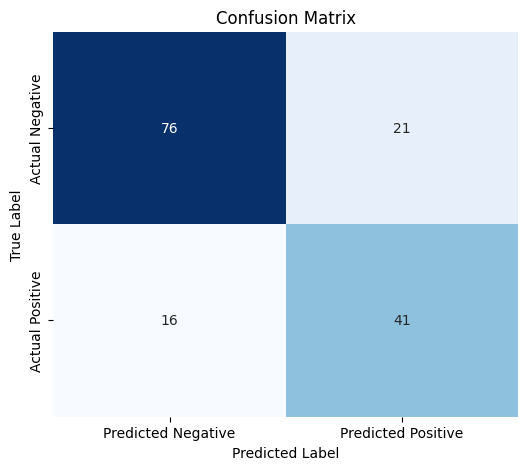

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate additional metrics
print("\nClassification Report:")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Đánh giá mô hình

Sau khi huấn luyện, chúng ta sẽ đánh giá hiệu suất của mô hình trên tập dữ liệu kiểm tra (`X_test`, `y_test`) để xem mô hình hoạt động tốt như thế nào trên dữ liệu mà nó chưa từng thấy.

Test Loss: 0.6202
Test Accuracy: 0.7597
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Classification Report:
Precision: 0.6667
Recall: 0.7018
F1-Score: 0.6838

Confusion Matrix:
[[77 20]
 [17 40]]


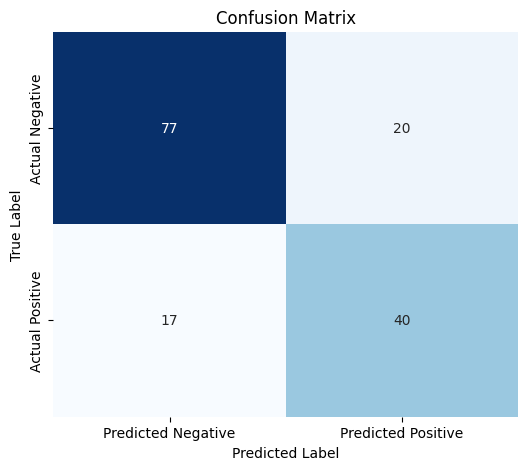

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate additional metrics
print("\nClassification Report:")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Trực quan hóa quá trình huấn luyện

Chúng ta có thể vẽ biểu đồ để xem độ chính xác (accuracy) và độ mất mát (loss) trong quá trình huấn luyện và trên tập validation qua từng epoch.

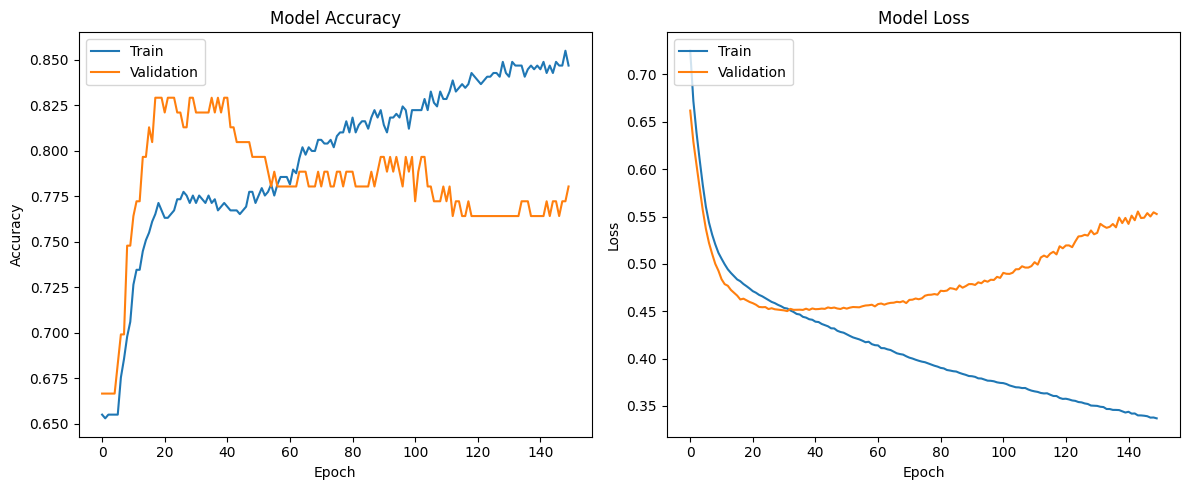

In [10]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

Đây là toàn bộ quá trình xây dựng và đánh giá mô hình ANN để dự đoán bệnh tiểu đường. Nếu bạn có bất kỳ câu hỏi nào hoặc muốn điều chỉnh mô hình, hãy cho tôi biết!

### Dự đoán trên một mẫu dữ liệu mới

Sau khi mô hình đã được huấn luyện, chúng ta có thể sử dụng nó để dự đoán kết quả cho một mẫu dữ liệu mới. Điều quan trọng là mẫu dữ liệu mới này cũng phải được tiền xử lý và chuẩn hóa tương tự như dữ liệu huấn luyện.

In [18]:
# Example of a new patient's data (replace with actual values)
# Order of features must match the training data: pregnancies, glucose, blood_pressure, skin_thickness, insulin, bmi, diabetes_pedigree_function, age

# *** Vui lòng thay đổi các giá trị bên dưới với thông số của bệnh nhân mới ***
# Ví dụ: [số_lần_mang_thai, glucose, huyết_áp, độ_dày_da, insulin, bmi, chức_năng_phả_hệ, tuổi]
new_patient_data = np.array([[2, 120, 70, 30, 100, 25.0, 0.5, 35]]) # Bạn có thể thay đổi các giá trị này

# Scale the new data using the same scaler fitted on the training data
new_patient_scaled = scaler.transform(new_patient_data)

# Make a prediction
prediction_probability = model.predict(new_patient_scaled)[0][0]
prediction_class = (prediction_probability > 0.5).astype(int)

print(f"Xác suất bị tiểu đường của bệnh nhân mới: {prediction_probability:.4f}")
if prediction_class == 1:
    print("Dự đoán: Bệnh nhân có nguy cơ mắc bệnh tiểu đường.")
else:
    print("Dự đoán: Bệnh nhân không có nguy cơ mắc bệnh tiểu đường.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Xác suất bị tiểu đường của bệnh nhân mới: 0.4902
Dự đoán: Bệnh nhân không có nguy cơ mắc bệnh tiểu đường.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Kiểm tra mô hình với các thông số tùy chỉnh

Bạn có thể tự nhập các thông số của bệnh nhân mới để xem mô hình dự đoán. Hãy đảm bảo nhập đủ 8 giá trị theo đúng thứ tự:

1.  **pregnancies**: Số lần mang thai
2.  **glucose**: Nồng độ Glucose
3.  **blood_pressure**: Huyết áp
4.  **skin_thickness**: Độ dày da
5.  **insulin**: Nồng độ Insulin
6.  **bmi**: Chỉ số BMI
7.  **diabetes_pedigree_function**: Chức năng phả hệ tiểu đường
8.  **age**: Tuổi

In [31]:
print("Vui lòng nhập 8 giá trị cho bệnh nhân mới:")

# Get user input for each feature
input_pregnancies = float(input("Số lần mang thai: "))
input_glucose = float(input("Nồng độ Glucose: "))
input_blood_pressure = float(input("Huyết áp: "))
input_skin_thickness = float(input("Độ dày da: "))
input_insulin = float(input("Nồng độ Insulin: "))
input_bmi = float(input("Chỉ số BMI: "))
input_dpf = float(input("Chức năng phả hệ tiểu đườn0g: "))
input_age = float(input("Tuổi: "))

# Create a NumPy array from the input values
custom_patient_data = np.array([[input_pregnancies, input_glucose, input_blood_pressure,
                                 input_skin_thickness, input_insulin, input_bmi,
                                 input_dpf, input_age]])

# Scale the custom data using the same scaler fitted on the training data
custom_patient_scaled = scaler.transform(custom_patient_data)

# Make a prediction with the custom data
custom_prediction_probability = model.predict(custom_patient_scaled)[0][0]
custom_prediction_class = (custom_prediction_probability > 0.5).astype(int)

print(f"\nXác suất bị tiểu đường của bệnh nhân mới (dựa trên dữ liệu nhập vào): {custom_prediction_probability:.4f}")
if custom_prediction_class == 1:
    print("Dự đoán: Bệnh nhân có nguy cơ mắc bệnh tiểu đường.")
else:
    print("Dự đoán: Bệnh nhân không có nguy cơ mắc bệnh tiểu đường.")

Vui lòng nhập 8 giá trị cho bệnh nhân mới:
Số lần mang thai: 0
Nồng độ Glucose: 108
Huyết áp: 73
Độ dày da: 27
Nồng độ Insulin: 102
Chỉ số BMI: 27.8
Chức năng phả hệ tiểu đườn0g: 0.412
Tuổi: 22
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Xác suất bị tiểu đường của bệnh nhân mới (dựa trên dữ liệu nhập vào): 0.0152
Dự đoán: Bệnh nhân không có nguy cơ mắc bệnh tiểu đường.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
